In [60]:
#!pip install pandas matplotlib jiwer

In [18]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from jiwer import wer, cer
import numpy as np

# All models

In [8]:
gold_dir = "gold_english"

model_dirs = {
    "GPT-5.4": "gpt_with_english_dataset/outputs/Experiment_1",
    "PaddleOCR": "paddleOCR_english_dataset/outputs/Experiment_1",
    "PyTesseract": "pytesseract_english_dataset/outputs/Experiment_1",
    "Qwen": "qwen_with_english_dataset/outputs/Experiment_1"
}

pages = range(1, 7)

In [20]:
output_dir = "resultsOfAllModel_en"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: resultsOfAllModel_en


In [9]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [10]:
results = []

for model, output_dir in model_dirs.items():
    for page in pages:
        with open(f"{gold_dir}/{page}.txt", encoding="utf-8") as f:
            gold = normalize_text(f.read())

        with open(f"{output_dir}/page_{page}.txt", encoding="utf-8") as f:
            prediction = normalize_text(f.read())

        results.append({
            "Model": model,
            "Page": page,
            "WER": wer(gold, prediction),
            "CER": cer(gold, prediction)
        })

In [12]:
df = pd.DataFrame(results)
#df

# Experiment-1

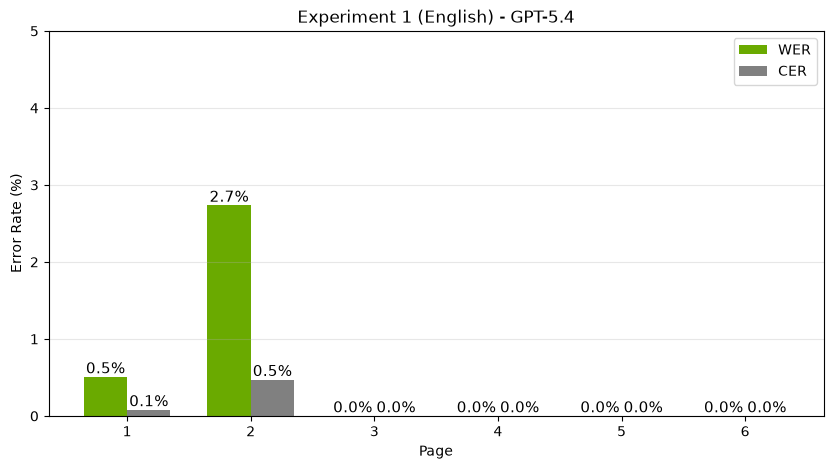

In [52]:
df_gpt = df[df["Model"] == "GPT-5.4"]

x = np.arange(len(df_gpt))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gpt["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_gpt["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_gpt["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - GPT-5.4")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 1))

save_path = os.path.join(
    output_dir,
    "experiment_1_gpt_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

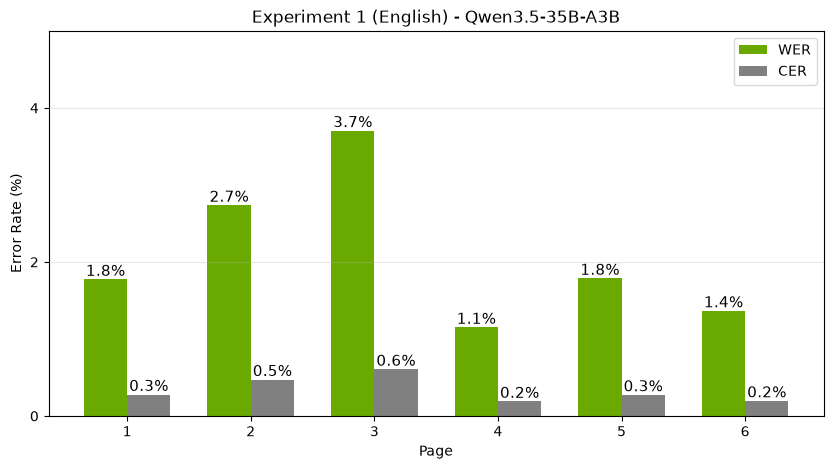

In [53]:
df_qwen = df[df["Model"] == "Qwen"]

x = np.arange(len(df_qwen))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_qwen["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_qwen["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_qwen["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - Qwen3.5-35B-A3B")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 2))

save_path = os.path.join(
    output_dir,
    "experiment_1_qwen_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

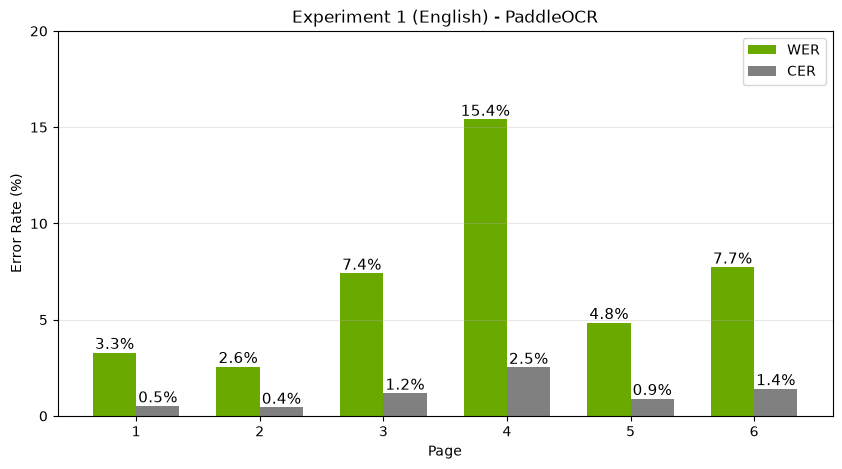

In [39]:
df_paddle = df[df["Model"] == "PaddleOCR"]

x = np.arange(len(df_paddle))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddle["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_paddle["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_paddle["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PaddleOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 5))

save_path = os.path.join(
    output_dir,
    "experiment_1_paddleocr_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

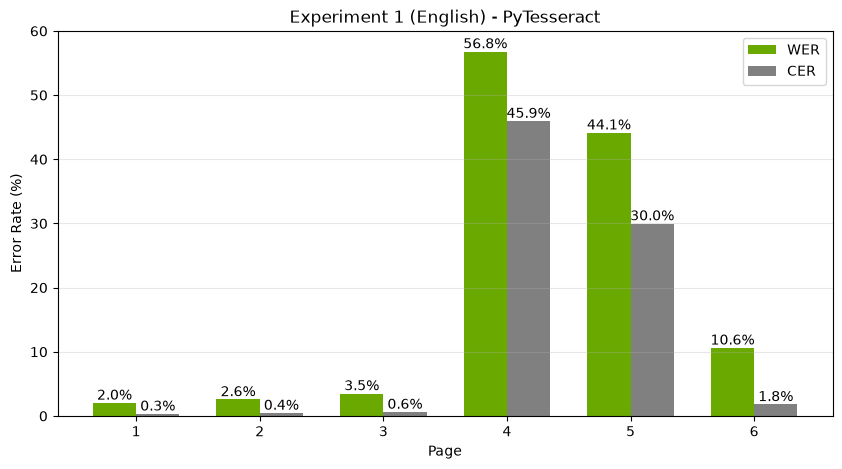

In [99]:
df_tesseract = df[df["Model"] == "PyTesseract"]

x = np.arange(len(df_tesseract))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_tesseract["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_tesseract["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_tesseract["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PyTesseract")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 60)
plt.yticks(np.arange(0, 61, 10))

save_path = os.path.join(
    output_dir,
    "experiment_1_pytesseract_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

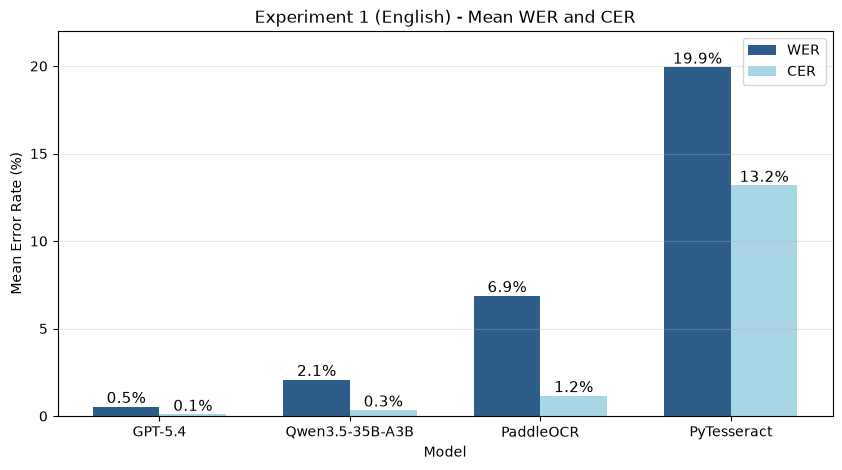

,Model,WER,CER
0,GPT-5.4,0.005402,0.000917
1,Qwen,0.020849,0.003347
2,PaddleOCR,0.068732,0.011602
3,PyTesseract,0.199326,0.131790


In [58]:
mean_df = df.groupby("Model")[["WER", "CER"]].mean().reset_index()

model_order = ["GPT-5.4", "Qwen", "PaddleOCR", "PyTesseract"]

mean_df["Model"] = pd.Categorical(
    mean_df["Model"],
    categories=model_order,
    ordered=True
)

mean_df = mean_df.sort_values("Model").reset_index(drop=True)

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    mean_df["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    mean_df["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(
    x,
    ["GPT-5.4", "Qwen3.5-35B-A3B", "PaddleOCR", "PyTesseract"],
    fontsize=10
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 1 (English) - Mean WER and CER")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    mean_df["WER"].max,
    mean_df["CER"].max()
) * 100

plt.ylim(0, 22)
plt.yticks(np.arange(0, 23, 5))
save_path = os.path.join(
    output_dir,
    "experiment_1_all_models_mean_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

mean_df

# Experiment-2

In [61]:
gold_dir = "gold_english"

model_dirs_exp2 = {
    "GPT-5.4": "gpt_with_english_dataset/outputs/Experiment_2",
    "Qwen": "qwen_with_english_dataset/outputs/Experiment_2",
    "PaddleOCR": "paddleOCR_english_dataset/outputs/Experiment_2",
    "PyTesseract": "pytesseract_english_dataset/outputs/Experiment_2"
}

pages = range(1, 7)

In [63]:
results_exp2 = []

for model, output_dir_exp2 in model_dirs_exp2.items():
    for page in pages:
        with open(f"{gold_dir}/{page}.txt", encoding="utf-8") as f:
            gold = normalize_text(f.read())

        with open(f"{output_dir_exp2}/page_{page}.txt", encoding="utf-8") as f:
            prediction = normalize_text(f.read())

        results_exp2.append({
            "Model": model,
            "Page": page,
            "WER": wer(gold, prediction),
            "CER": cer(gold, prediction)
        })

In [65]:
df_exp2 = pd.DataFrame(results_exp2)
#df_exp2

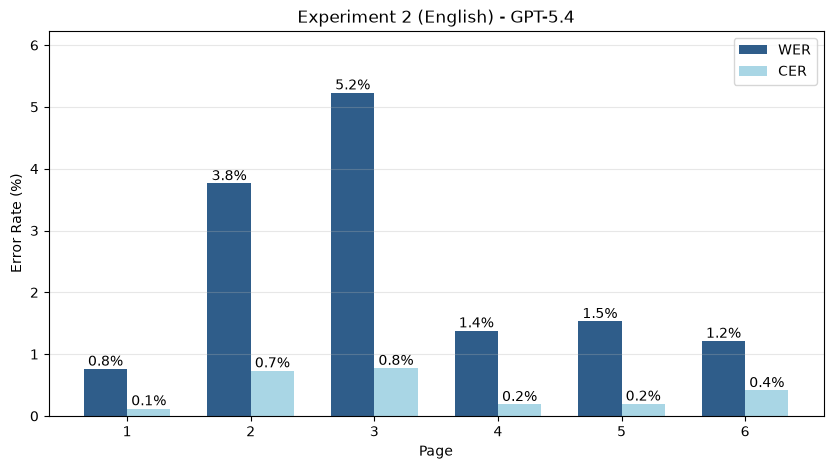

In [95]:
df_gpt_exp2 = df_exp2[df_exp2["Model"] == "GPT-5.4"]

x = np.arange(len(df_gpt_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gpt_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_gpt_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_gpt_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - GPT-5.4")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_gpt_exp2["WER"].max(),
    df_gpt_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_gpt_graph.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

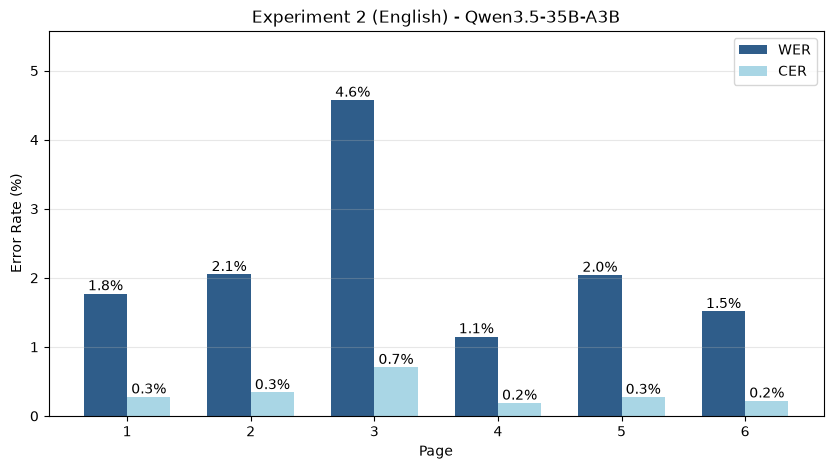

In [94]:
df_qwen_exp2 = df_exp2[df_exp2["Model"] == "Qwen"]

x = np.arange(len(df_qwen_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_qwen_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_qwen_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_qwen_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - Qwen3.5-35B-A3B")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_qwen_exp2["WER"].max(),
    df_qwen_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_qwen_graph.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

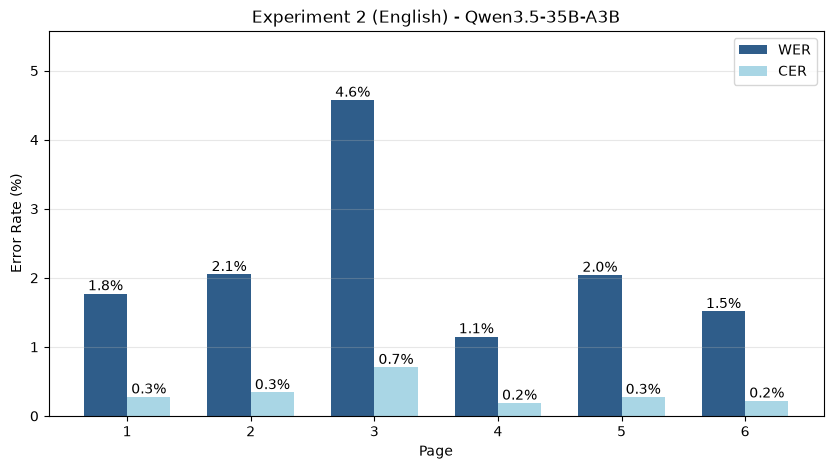

In [85]:
plot_exp2_model("Qwen","Qwen3.5-35B-A3B",
    "experiment_2_qwen_graph.pdf"
)

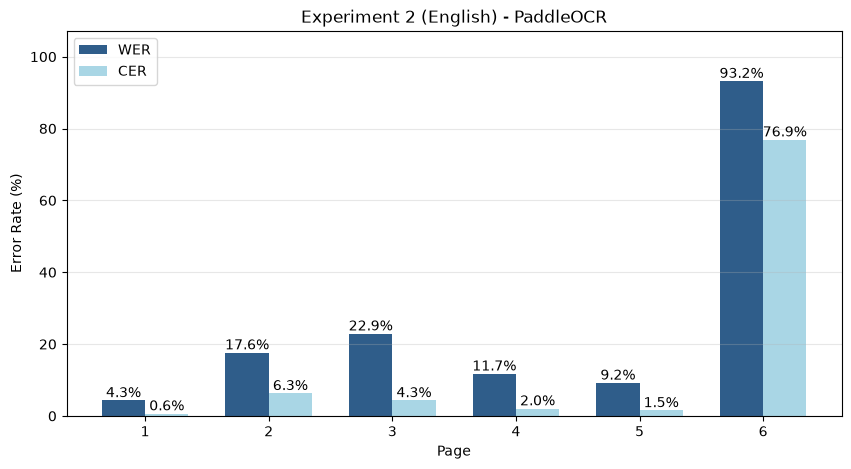

In [93]:
df_paddle_exp2 = df_exp2[df_exp2["Model"] == "PaddleOCR"]

x = np.arange(len(df_paddle_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddle_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_paddle_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_paddle_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - PaddleOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_paddle_exp2["WER"].max(),
    df_paddle_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_paddleocr_graph.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

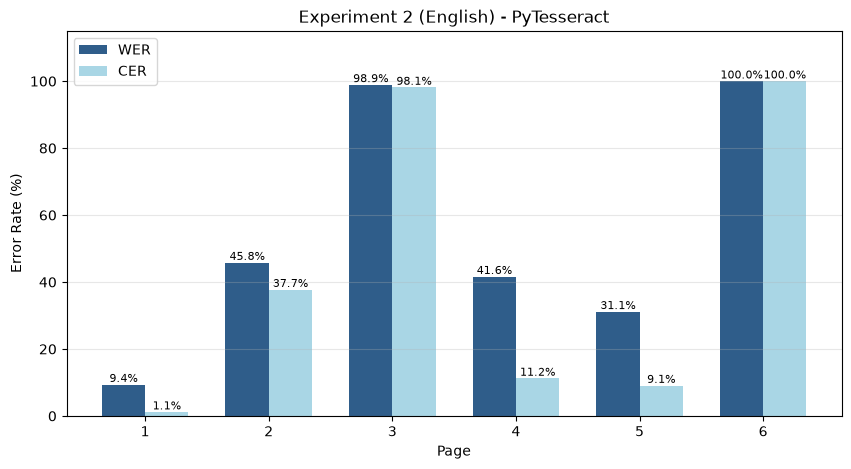

In [98]:
df_tesseract_exp2 = df_exp2[df_exp2["Model"] == "PyTesseract"]

x = np.arange(len(df_tesseract_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_tesseract_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_tesseract_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x, df_tesseract_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - PyTesseract")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_tesseract_exp2["WER"].max(),
    df_tesseract_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_pytesseract_graph.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

In [74]:
mean_exp2 = (
    df_exp2
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

mean_exp2

,Model,WER,CER
0,GPT-5.4,0.023118,0.004033
1,PaddleOCR,0.264793,0.152733
2,PyTesseract,0.544702,0.428784
3,Qwen,0.021840,0.003337


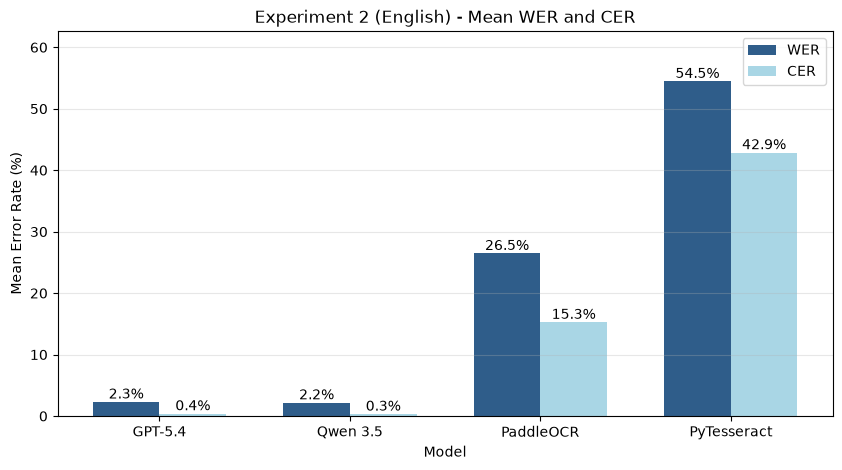

In [100]:
model_order = ["GPT-5.4", "Qwen", "PaddleOCR", "PyTesseract"]

mean_exp2["Model"] = pd.Categorical(
    mean_exp2["Model"],
    categories=model_order,
    ordered=True
)

mean_exp2 = mean_exp2.sort_values("Model").reset_index(drop=True)

x = np.arange(len(mean_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    mean_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    mean_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(
    x,
    ["GPT-5.4", "Qwen 3.5", "PaddleOCR", "PyTesseract"]
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 2 (English) - Mean WER and CER")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    mean_exp2["WER"].max(),
    mean_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_all_models_mean_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()